# Notebook 1 — XOR Encrypt / Decrypt

**Input:**  `Train_Test_IoT_Modbus.csv` (original)  
**Outputs:** `data_xor_encrypted.csv` + `data_xor_decrypted.csv`

---
### How XOR works here
```
Encrypt:  register_value  XOR  key  =  encrypted_value
Decrypt:  encrypted_value XOR  key  =  original_value   (XOR is self-inverse)
```
The key stream is generated from a shared PRNG seed.  
Anyone without the seed cannot reverse the encryption.

---

In [5]:
import pandas as pd
import numpy as np

# ── Config ────────────────────────────────────────────────────────────────────
INPUT_FILE       = 'Train_Test_IoT_GPS_Tracker.csv' #'Train_Test_IoT_Modbus.csv'
ENCRYPTED_FILE   = 'data_xor_encrypted1.csv'
DECRYPTED_FILE   = 'data_xor_decrypted1.csv'

SHARED_SECRET    = 999          # PRNG seed — acts as the secret key
MODBUS_MAX       = 65535        # 16-bit register ceiling

# Modbus register columns — only these get perturbed
FC_COLS = [
    'latitude',
    'longitude'
]

print('Config loaded.')
print(f'  Secret seed  : {SHARED_SECRET}')
print(f'  Key range    : 0 – {MODBUS_MAX}')
print(f'  Columns      : {FC_COLS}')

Config loaded.
  Secret seed  : 999
  Key range    : 0 – 65535
  Columns      : ['latitude', 'longitude']


## Step 1 — Load Original Data

In [6]:
df_original = pd.read_csv(INPUT_FILE)

print(f'Loaded: {INPUT_FILE}')
print(f'Shape : {df_original.shape}')
print(f'\nFirst 3 rows (FC columns):')
print(df_original[FC_COLS].head(3).to_string())

Loaded: Train_Test_IoT_GPS_Tracker.csv
Shape : (38960, 6)

First 3 rows (FC columns):
     latitude   longitude
0  116.521704  132.162504
1  121.742933  135.072500
2  121.795929  135.110198


## Step 2 — XOR Encrypt

In [13]:
import time

df_enc = df_original.copy()

# Extract register values as uint16 (native Modbus type)
X_original = df_original[FC_COLS].values.astype(np.uint16)

# Generate key stream from shared secret
# Same seed → same key stream → guaranteed reversibility
np.random.seed(SHARED_SECRET)
key_stream = np.random.randint(
    low  = 0,
    high = MODBUS_MAX + 1,
    size = X_original.shape,
    dtype= np.uint16
)

t0 = time.time()
X_encrypted = np.bitwise_xor(X_original, key_stream)
enc_ms = (time.time() - t0) * 1000

# Write back — metadata columns (date, time, label, type) stay untouched
df_enc[FC_COLS] = X_encrypted.astype(int)

# Save
df_enc.to_csv(ENCRYPTED_FILE, index=False)

print(f'Encrypted and saved → {ENCRYPTED_FILE}')
print(f'Encryption time     : {enc_ms:.4f} ms  ({len(df_enc):,} rows)')
print(f'Time per sample     : {enc_ms/len(df_enc)*1000:.4f} µs')
print()
print('Original vs Encrypted (first 5 rows, FC1):')
comparison = pd.DataFrame({
    'Original'  : df_original[FC_COLS[0]].values[:5],
    'Encrypted' : df_enc[FC_COLS[0]].values[:5],
})
print(comparison.to_string(index=False))

Encrypted and saved → data_xor_encrypted1.csv
Encryption time     : 0.5419 ms  (38,960 rows)
Time per sample     : 0.0139 µs

Original vs Encrypted (first 5 rows, FC1):
  Original  Encrypted
116.521704      30132
121.742933      12581
121.795929      45852
116.611216      16789
121.841526       5809


## Step 3 — Verify Encryption (distribution shift)

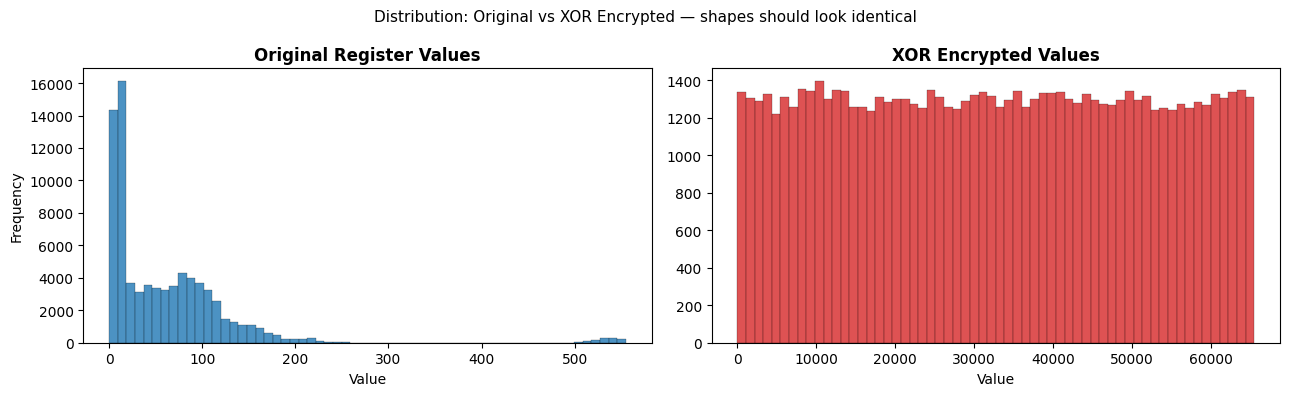


Descriptive stats comparison:
  lati  original mean=55.5  encrypted mean=32800.2
  long  original mean=65.8  encrypted mean=32624.7

The means will differ — that is expected and intended.
The SHAPE of the distribution (uniform) is preserved.


In [9]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].hist(X_original.flatten(), bins=60,
             color='#1f77b4', alpha=0.8, edgecolor='black', linewidth=0.2)
axes[0].set_title('Original Register Values', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Value'); axes[0].set_ylabel('Frequency')

axes[1].hist(X_encrypted.flatten(), bins=60,
             color='#d62728', alpha=0.8, edgecolor='black', linewidth=0.2)
axes[1].set_title('XOR Encrypted Values', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Value')

plt.suptitle('Distribution: Original vs XOR Encrypted — shapes should look identical',
             fontsize=11)
plt.tight_layout()
plt.show()

print('\nDescriptive stats comparison:')
for col in FC_COLS:
    orig_mean = df_original[col].mean()
    enc_mean  = df_enc[col].mean()
    print(f'  {col[:4]}  original mean={orig_mean:.1f}  encrypted mean={enc_mean:.1f}')
print()
print('The means will differ — that is expected and intended.')
print('The SHAPE of the distribution (uniform) is preserved.')

## Step 4 — XOR Decrypt

In [10]:
# Load encrypted file (simulates cloud-side receiving it)
df_to_decrypt = pd.read_csv(ENCRYPTED_FILE)

X_enc_loaded = df_to_decrypt[FC_COLS].values.astype(np.uint16)

# Regenerate SAME key stream with same seed
np.random.seed(SHARED_SECRET)
key_stream_decrypt = np.random.randint(
    low  = 0,
    high = MODBUS_MAX + 1,
    size = X_enc_loaded.shape,
    dtype= np.uint16
)

# XOR again — self-inverse operation
X_decrypted = np.bitwise_xor(X_enc_loaded, key_stream_decrypt)

df_dec = df_to_decrypt.copy()
df_dec[FC_COLS] = X_decrypted.astype(int)

df_dec.to_csv(DECRYPTED_FILE, index=False)

print(f'Decrypted and saved → {DECRYPTED_FILE}')

Decrypted and saved → data_xor_decrypted1.csv


## Step 5 — Verify Perfect Restoration

RESTORATION VERIFICATION
  Max error        : 0
  Mean error       : 0.0
  Perfect match    : True
  Total cells      : 77,920
  Mismatched cells : 0

✅ RESULT: 100% perfect restoration. Zero data loss.


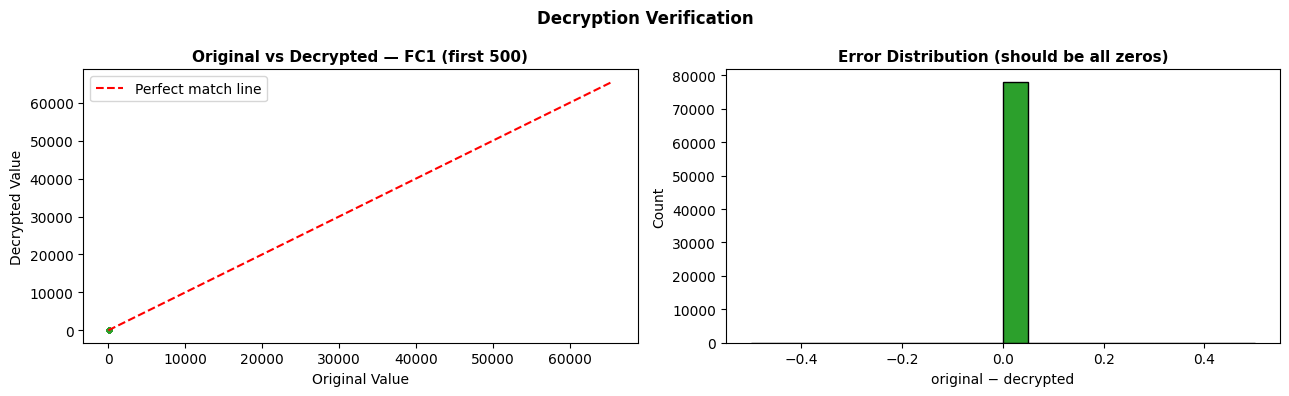

In [11]:
# Compare original vs decrypted value-by-value
X_orig_check = df_original[FC_COLS].values.astype(int)
X_dec_check  = df_dec[FC_COLS].values.astype(int)

max_error  = np.abs(X_orig_check - X_dec_check).max()
mean_error = np.abs(X_orig_check - X_dec_check).mean()
exact_match = np.array_equal(X_orig_check, X_dec_check)

print('=' * 50)
print('RESTORATION VERIFICATION')
print('=' * 50)
print(f'  Max error        : {max_error}')
print(f'  Mean error       : {mean_error}')
print(f'  Perfect match    : {exact_match}')
print(f'  Total cells      : {X_orig_check.size:,}')
print(f'  Mismatched cells : {(X_orig_check != X_dec_check).sum()}')
print('=' * 50)

if exact_match:
    print('\n✅ RESULT: 100% perfect restoration. Zero data loss.')
else:
    print('\n⚠ Mismatch detected — check seed or dtype.')

# Visual confirmation
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].scatter(X_orig_check[:500, 0], X_dec_check[:500, 0],
                alpha=0.4, s=8, color='#2ca02c')
axes[0].plot([0, 65535], [0, 65535], 'r--', linewidth=1.5,
             label='Perfect match line')
axes[0].set_title('Original vs Decrypted — FC1 (first 500)',
                   fontsize=11, fontweight='bold')
axes[0].set_xlabel('Original Value'); axes[0].set_ylabel('Decrypted Value')
axes[0].legend()

diff = X_orig_check.flatten() - X_dec_check.flatten()
axes[1].hist(diff, bins=20, color='#2ca02c', edgecolor='black')
axes[1].set_title('Error Distribution (should be all zeros)',
                   fontsize=11, fontweight='bold')
axes[1].set_xlabel('original − decrypted')
axes[1].set_ylabel('Count')

plt.suptitle('Decryption Verification', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

## Step 6 — Summary

In [12]:
print('FILES PRODUCED')
print('-' * 45)
print(f'  {ENCRYPTED_FILE:<35} ← send to attacker notebook')
print(f'  {DECRYPTED_FILE:<35} ← send to cloud notebook')
print()
print('NEXT STEPS')
print('-' * 45)
print('  1. Run analysis_pipeline.ipynb on data_xor_encrypted.csv')
print('     → attacker accuracy should be ~50% (privacy proven)')
print()
print('  2. Run analysis_pipeline.ipynb on data_xor_decrypted.csv')
print('     → accuracy should match original baseline (utility proven)')

FILES PRODUCED
---------------------------------------------
  data_xor_encrypted1.csv             ← send to attacker notebook
  data_xor_decrypted1.csv             ← send to cloud notebook

NEXT STEPS
---------------------------------------------
  1. Run analysis_pipeline.ipynb on data_xor_encrypted.csv
     → attacker accuracy should be ~50% (privacy proven)

  2. Run analysis_pipeline.ipynb on data_xor_decrypted.csv
     → accuracy should match original baseline (utility proven)
